In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler


In [94]:
df=pd.read_csv("Titanic_new.csv")

In [95]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
320,321,0,3,"Dennis, Mr. Samuel",male,22.0,0,0,A/5 21172,7.2500,NaN,S
163,164,0,3,"Calic, Mr. Jovo",male,17.0,0,0,315093,8.6625,NaN,S
103,104,0,3,"Johansson, Mr. Gustaf Joel",male,33.0,0,0,7540,8.6542,NaN,S
381,382,1,3,"Nakid, Miss. Maria (""Mary"")",female,1.0,0,2,2653,15.7417,NaN,C
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0000,NaN,S
569,570,1,3,"Jonsson, Mr. Carl",male,32.0,0,0,350417,7.8542,NaN,S
556,557,1,1,"Duff Gordon, Lady. (Lucille Christiana Sutherl...",female,48.0,1,0,11755,39.6000,A16,C
170,171,0,1,"Van der hoef, Mr. Wyckoff",male,61.0,0,0,111240,33.5000,B19,S
675,676,0,3,"Edvardsson, Mr. Gustaf Hjalmar",male,18.0,0,0,349912,7.7750,NaN,S
674,675,0,2,"Watson, Mr. Ennis Hastings",male,NaN,0,0,239856,0.0000,NaN,S


In [96]:
df=df.drop(columns=["Name","Ticket","Cabin","Sex"])

In [97]:
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,22.0,1,0,7.2500,S
1,2,1,1,38.0,1,0,71.2833,C
2,3,1,3,26.0,0,0,7.9250,S
3,4,1,1,35.0,1,0,53.1000,S
4,5,0,3,35.0,0,0,8.0500,S


In [98]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
dtype: int64

In [102]:
df.fillna(df["Age"].mean(), inplace=True)

TypeError: Invalid value '29.69911764705882' for dtype 'str'. Value should be a string or missing value, got 'float64' instead.

In [103]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       2
dtype: int64

In [104]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [105]:
X_train,X_test,y_train,y_test=train_test_split(
                                df.drop(["Survived"],axis=1),
                                df["Survived"],
                                test_size=.3,
                                random_state=42)

In [106]:
X_train.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Embarked
445,446,1,4.000000,0,2,81.8583,S
650,651,3,29.699118,0,0,7.8958,S
172,173,3,1.000000,1,1,11.1333,S
450,451,2,36.000000,1,2,27.7500,S
314,315,2,43.000000,1,1,26.2500,S


In [107]:
X_test.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Embarked
709,710,3,29.699118,1,1,15.2458,C
439,440,2,31.000000,0,0,10.5000,S
840,841,3,20.000000,0,0,7.9250,S
720,721,2,6.000000,0,1,33.0000,S
39,40,3,14.000000,1,0,11.2417,C


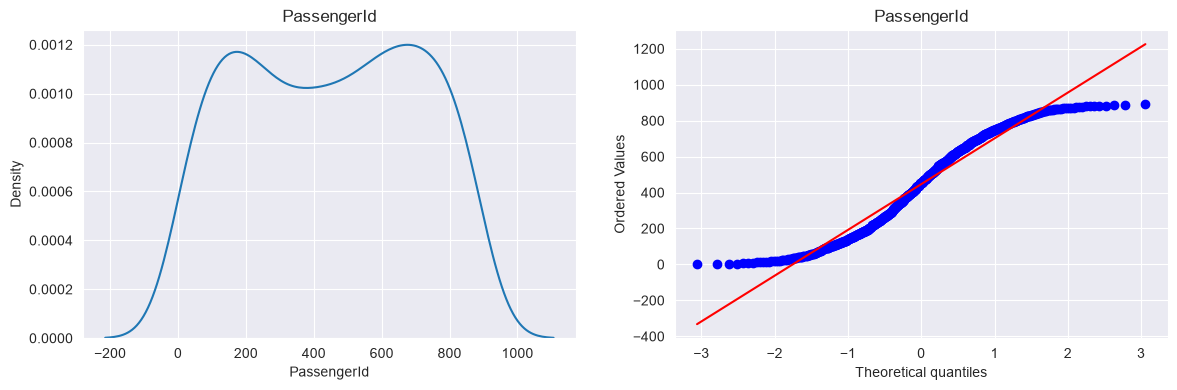

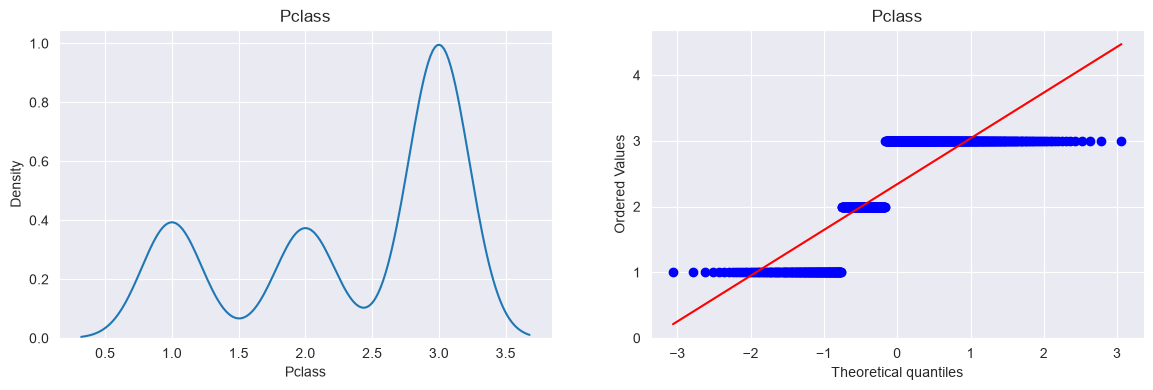

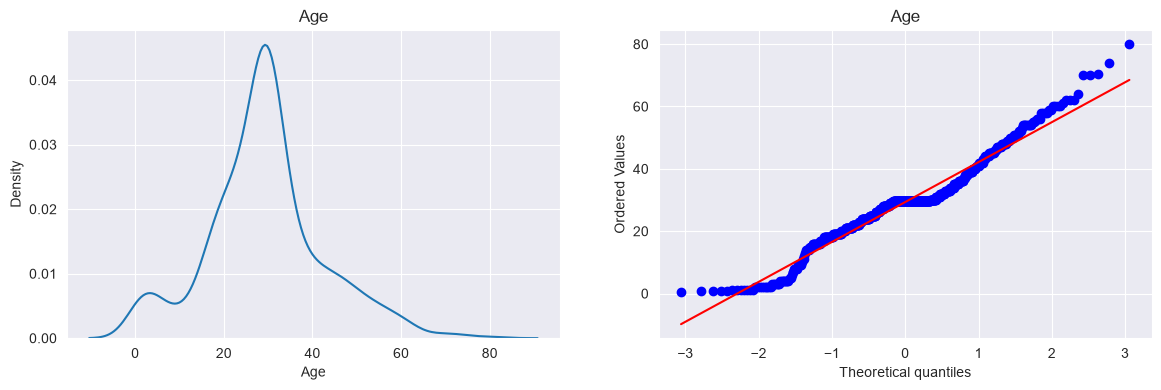

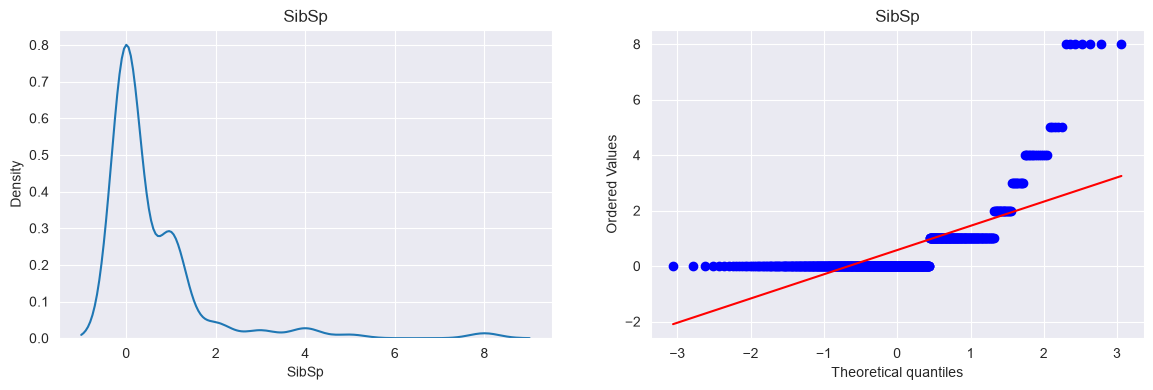

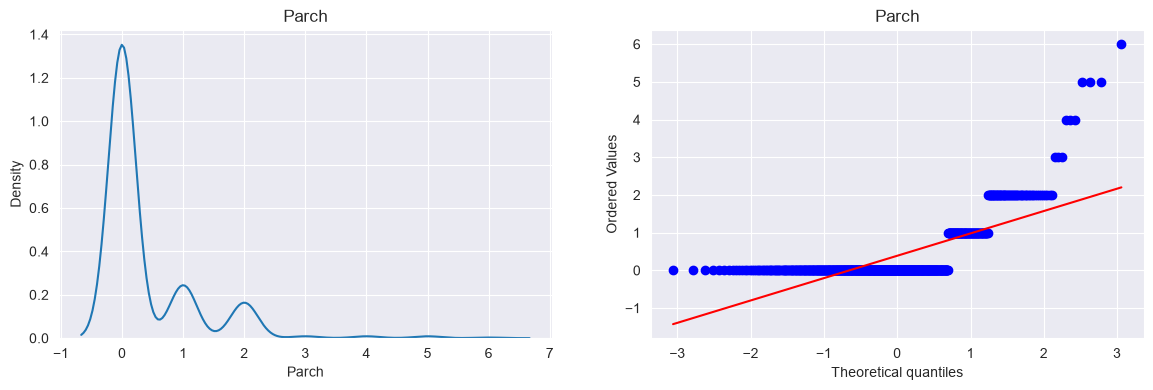

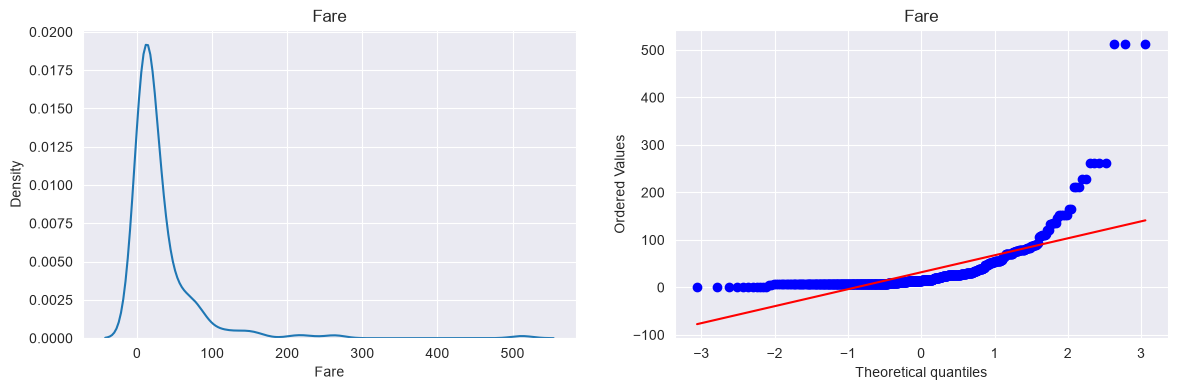

TypeError: The x variable is categorical, but one of ['numeric', 'datetime'] is required

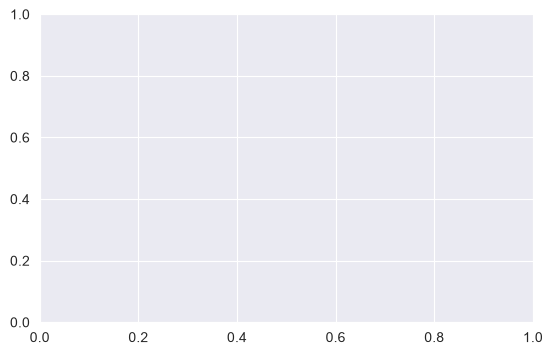

In [108]:
for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)
    plt.show()

In [59]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [60]:
lr= LogisticRegression()
lr.fit(X_train_scaled,y_train)
y_pred=lr.predict(X_test_scaled)
score=accuracy_score(y_pred,y_test)
score

0.7313432835820896

In [65]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # not fit_transform

In [66]:
trf=PowerTransformer(method="yeo-johnson")
X_train_scaled_transformed=trf.fit_transform(X_train_scaled+0.0000000001)
X_test_scaled_transformed=trf.fit_transform(X_test_scaled+0.000000000001)

In [67]:
lr=LogisticRegression()
lr.fit(X_train_scaled_transformed,y_train)
y_pred=lr.predict(X_test_scaled_transformed)
score=accuracy_score(y_pred,y_test)
score

0.7276119402985075

In [69]:
X_train_scaled_transformed = pd.DataFrame(
    X_train_scaled_transformed,
    columns=X_train.columns
)

X_test_scaled_transformed = pd.DataFrame(
    X_test_scaled_transformed,
    columns=X_test.columns
)

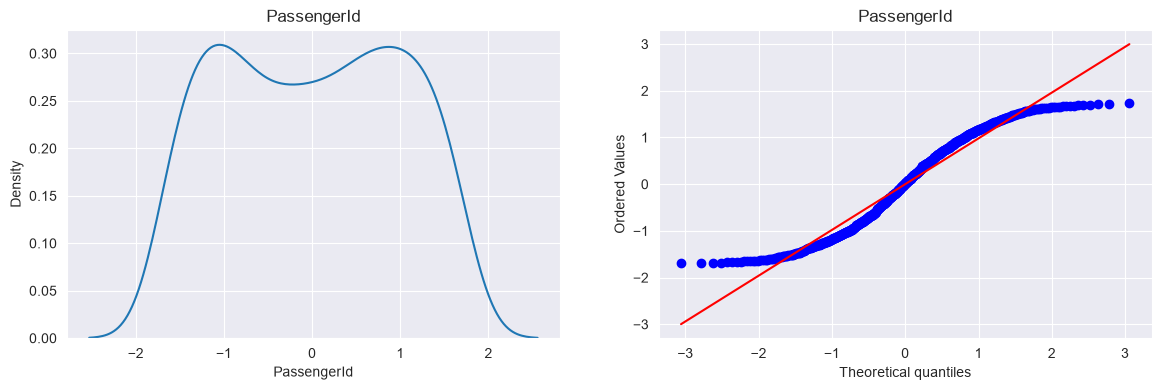

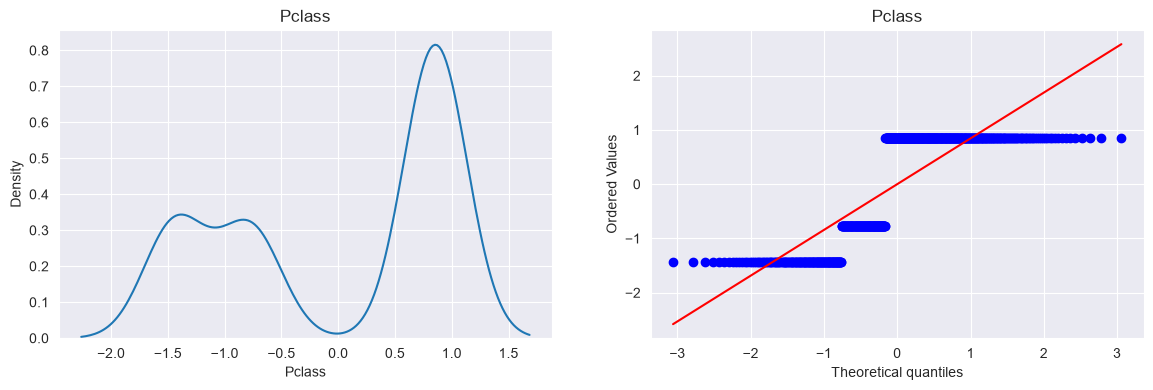

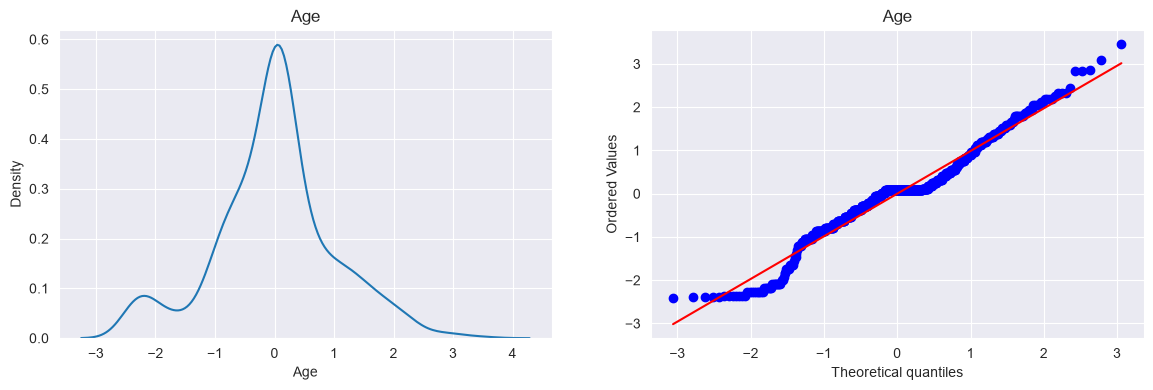

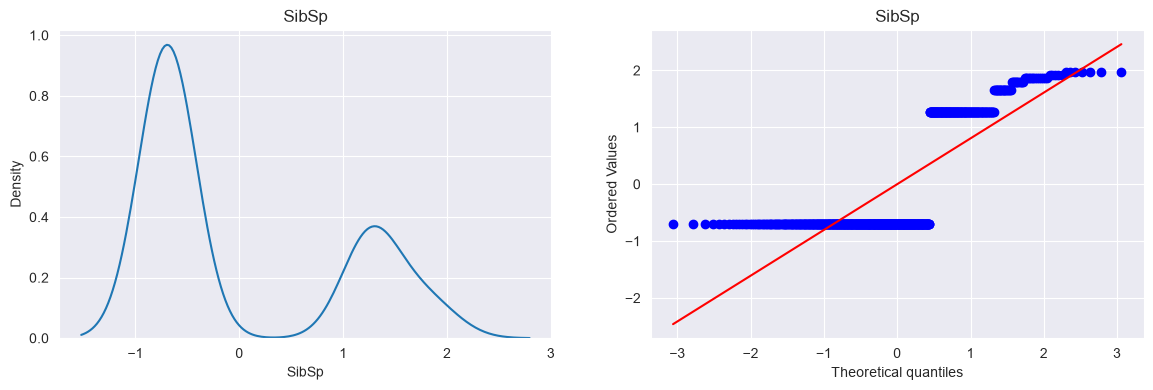

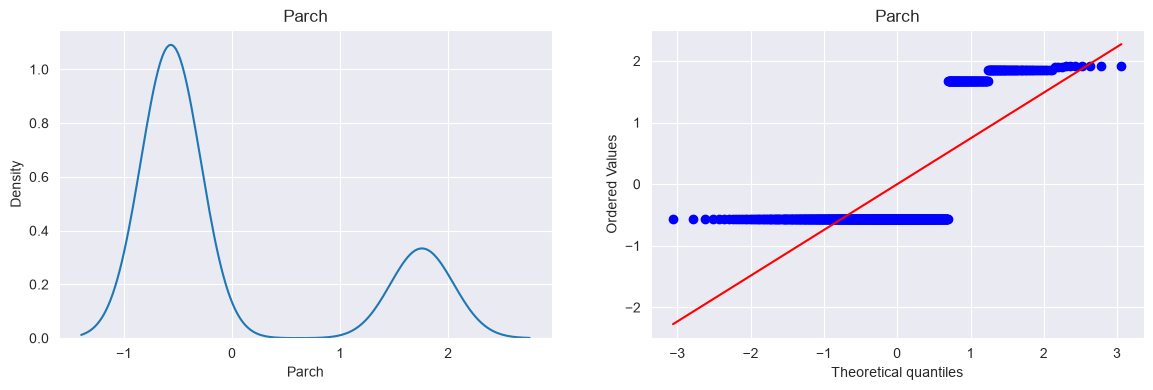

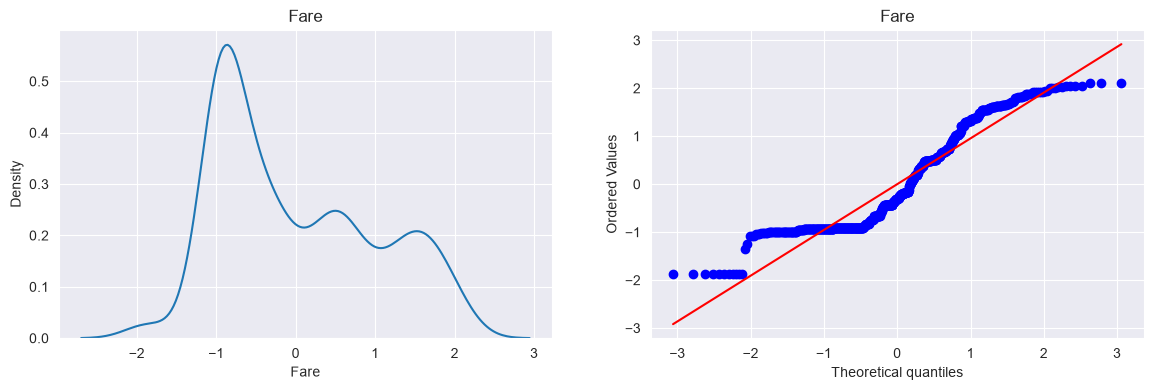

In [71]:
for col in X_train_scaled_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(X_train_scaled_transformed[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train_scaled_transformed[col], dist="norm", plot=plt)
    plt.title(col)
    plt.show()
